### Import Dependencies

In [25]:
import openai
from qdrant_client import QdrantClient, models
from qdrant_client.models import Document, Prefetch
import cohere
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, convert_to_openai_messages
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from typing import Annotated, List, Any
from operator import add
import random
from jinja2 import Template
import instructor
from langsmith import traceable, get_current_run_tree

### Agent Graph wih ReAct

In [41]:
@traceable(
    name='embed_query',
    run_type='embedding',
    metadata={
        'ls_provider': 'openai',
        'ls_model_name': 'text-embedding-3-small',
    },
)
def get_embedding(text, model='text-embedding-3-small'):
    response = openai.embeddings.create(
        model=model,
        input=text,
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata['usage_metadata'] = {
            'input_tokens': response.usage.prompt_tokens,
            'total_tokens': response.usage.total_tokens,
        }
    
    return response.data[0].embedding

@traceable(
    name='retrieve_data',
    run_type='retriever',
)
def retrieve_data(query, qdrant_client, collection_name='amazon-items-collection-01-hybrid-search', k=5):
    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name=collection_name,
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context_scores = []
    retrieved_context_texts = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_context_scores.append(result.score)
        retrieved_context_texts.append(result.payload['processed_description'])
        retrieved_context_ratings.append(result.payload['average_rating'])

    return {
        'retrieved_context_ids': retrieved_context_ids,
        'retrieved_context_scores': retrieved_context_scores,
        'retrieved_context_texts': retrieved_context_texts,
        'retrieved_context_ratings': retrieved_context_ratings
    }

@traceable(
    name='rerank_data',
    run_type='tool'
)
def rerank_data(query, context, top_k=5):
    cohere_client = cohere.ClientV2()

    response = cohere_client.rerank(
        model='rerank-v4.0-pro',
        query=query,
        documents=context['retrieved_context_texts'],
        top_n=top_k
    )

    order = [result.index for result in response.results]

    return {
        'retrieved_context_ids': [context['retrieved_context_ids'][i] for i in order],
        'retrieved_context_texts': [context['retrieved_context_texts'][i] for i in order],
        'similarity_scores': [context['retrieved_context_scores'][i] for i in order],
        'retrieved_context_ratings': [context['retrieved_context_ratings'][i] for i in order]
    }
    
@traceable(
    name='format_retrieved_context',
    run_type='prompt',
)
def process_context(retrieve_context):
    formatted_context = ''

    for id, chunk, rating in zip(retrieve_context['retrieved_context_ids'], retrieve_context['retrieved_context_texts'], retrieve_context['retrieved_context_ratings']):
        formatted_context += f"- Product ID: {id}, Product Rating: {rating}, Product Description: {chunk}\n"

    return formatted_context

@tool
def get_formatted_item_context(query: str, top_k: int = 5) -> str:
    """
    Get the top_k context, each representing an inventory item for a given query
    Args:
        query: The query to get the top k context for
        top_k: The number of context chunks to retrieve, works best with 5 or more
    Returns:
        A string of the top_k context chunks with IDs and average ratings prepeding each chunk, each representing an inventory item for a given query
    """

    qdrant_client = QdrantClient(url="http://localhost:6333")

    retrieved_context = retrieve_data(
        query, 
        qdrant_client, 
        k=20
    )

    retrieved_context = rerank_data(query,retrieved_context,top_k=top_k)
    formatted_context = process_context(retrieved_context)

    return formatted_context

### State and Pydantic models for Structured Outputs

In [31]:
class RAGUsedContext(BaseModel):
    id: str = Field(description="The ID of the item used to answer the question")
    description: str = Field(description="The description of the item used to answer the question")

class FinalResponse(BaseModel):
    answer: str = Field(description="The answer to the user's question")
    references: list[RAGUsedContext] = Field(description="List of items used to answer the question")

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    question_relevant: bool = False
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    references: list[RAGUsedContext] = []

In [32]:
@traceable(
    name= "agent_node",
    run_type= "llm",
    metadata= {
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)
def agent_node(state: State) -> dict:
    prompt_template = f"""
    You are a shopping assistant that answers questions about products in stock.

    ## Instructions
    - Use the available tools to answer the user's question. Do not fabricate product details
    - When a questions involves multiple products or sub-questions, issue all the tools calls at once. Never repeat a tool call you have already made.
    - When describing the product, include the details using bullet points
    - If tools return no relevant resulkts, tell the customer and ask them to refine their query
    - Only answer questions about products in stock. If a question is unrelated, ask the customer to refine their query and include what products they are looking for
    - In references, include every chunk that contributed to the answer, with the chunk ID and product name
    - Refer to retrieved data as "available products", never as "context"
    - Try answering queries that are not precise, if speficic names or brands are missing apply broad searches
    """

    template = Template(prompt_template)
    prompt = template.render()

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort = "none",
        use_responses_api=True,
    )

    llm_with_tools = llm.bind_tools(
        [get_formatted_item_context, FinalResponse],
        tool_choice="any"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages #this lets the model reference the previous messages (the history)
        ]
    )

    final_answer = False
    answer = ""
    references = []

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get('name') == "FinalResponse":
                final_answer = True
                answer = tool_call.get('args').get('answer')
                references.extend(tool_call.get('args').get('references'))
                

    return {
        "messages": [response],
        "final_answer": final_answer,
        "iteration": state.iteration + 1,
        "answer": answer,
        "references": references
    }

In [33]:
def tool_router(state: State) -> str:
    if state.final_answer == True:
        return "end"
    elif state.iteration > 2:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

### User intent Router Node

In [51]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="An answer to the question if it's not relevant, saying that the question is not relevant to the products in stock")

In [52]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)

def intent_router_node(state: State) -> dict:
    prompt_template = """
    You are a relevance router for a shopping assistant that answers questions about products in stock. Your goal is to determine whether the question asked by the customer is relevant or not.

    ## Instructions:
    - If the question is about products, availability, pricing, comparisons and product recommendations, label the question as relevant
    - If the question is about store policies, personal advice, or unrelated topics, label the question as not relevant
    """
    template = Template(prompt_template)
    prompt = template.render()

    messages = state.messages
    conversation = []
    
    for message in messages:
        conversation.append(convert_to_openai_messages(message))

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
            *conversation
        ],
        response_model=IntentRouterResponse,
        reasoning={"effort":"none"}
    )
    return {
        'question_relevant': response.question_relevant,
        'answer': response.answer
    }

In [53]:
def intent_router_conditional_edges(state: State) -> str:
    if state.question_relevant:
        return "agent_node"
    else:
        return "end"

### Graph layout

In [54]:
workflow = StateGraph(State)

tools = [get_formatted_item_context]

tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END 
    }
)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END 
    }
)

workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()

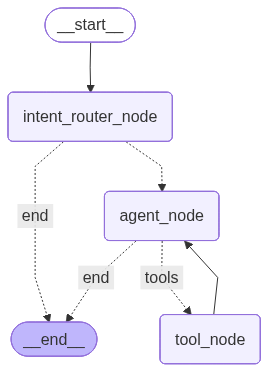

In [55]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
initial_state = {
    "messages": [HumanMessage(content="Can I get a tablet for me, a watch for my wife and a laptop for my daughter?")]
}

In [45]:
result = graph.invoke(initial_state)

In [46]:
result

{'messages': [HumanMessage(content='Can I get a tablet for me, a watch for my wife and a laptop for my daughter?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'arguments': '{"query":"tablet products in stock", "top_k": 5}', 'call_id': 'call_HgsKLuUWpXWekfMxZXmUT0mr', 'name': 'get_formatted_item_context', 'type': 'function_call', 'id': 'fc_0ecb9587c8bbdcc0006a52a64c487481a1864c09ff260d0f96', 'status': 'completed'}, {'arguments': '{"query":"watch products in stock", "top_k": 5}', 'call_id': 'call_vO4T5PNbkpUMXMpFRH5jNaJK', 'name': 'get_formatted_item_context', 'type': 'function_call', 'id': 'fc_0ecb9587c8bbdcc0006a52a64c488481a18704b73a380068ce', 'status': 'completed'}, {'arguments': '{"query":"laptop products in stock", "top_k": 5}', 'call_id': 'call_UUubxTVWFZk7k01u5Dd1IFQq', 'name': 'get_formatted_item_context', 'type': 'function_call', 'id': 'fc_0ecb9587c8bbdcc0006a52a64c488c81a18d4d5c3c7e219ea4', 'status': 'completed'}], additional_kwargs={}, response_metadata

In [47]:
print(result['answer'])

Yes — here are some available products that fit what you’re looking for:

**Tablet options for you**
- **B09RHF4L45 — plimpton Android Tablet 10 inch**
  - 10.1-inch display
  - 4GB RAM, 64GB storage
  - Android 11
  - 6000mAh battery
  - Wi‑Fi only
- **B0BCFYCXRH — TECLAST Tablet 10 inch Android 12**
  - 10.1-inch IPS display
  - 3GB RAM, 64GB storage
  - Android 12
  - Wi‑Fi 6 support
  - 5000mAh battery

**Watch options for your wife**
- **B0CFLR6R3X — SOUYIE Smart Watch for Men Women**
  - Bluetooth calling
  - 1.8-inch HD display
  - Blood pressure, heart rate, temperature, and sleep monitoring
  - IP67 waterproof
- **B09PR6VKFC — TOZO S2 Smart Watch**
  - Alexa built-in
  - 1.69-inch HD touchscreen
  - Heart rate, sleep, blood oxygen, and activity tracking
  - 5ATM waterproof
- **B09KLYPYTN — Smart Watch Compatible with iPhone Android Phones**
  - 1.7-inch color screen
  - Heart rate and blood oxygen monitoring
  - IP68 waterproof
  - Up to 7 days use

**Laptop options for your d

In [56]:
initial_state = {
    "messages": [HumanMessage(content="Who won the world cup in 2022?")]
}

In [57]:
result = graph.invoke(initial_state)

In [58]:
result

{'messages': [HumanMessage(content='Who won the world cup in 2022?', additional_kwargs={}, response_metadata={})],
 'question_relevant': False,
 'answer': 'This question is not relevant to the products in stock.'}